# Промежуточная аттестация 1 — EDA (develop_issues)

**Целевая переменная:** `is_sla_breached` (1 = нарушен SLA, 0 = в срок)

**Шаги:**
1. Загрузка готового CSV (выгрузка витрины `v_attestation_ml`)
2. Разведочный анализ (пропуски, статистика)
3. Простая очистка данных
4. Графики связи признаков с целевой переменной


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "data"
FIGURES_DIR = BASE_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RAW_CSV = DATA_DIR / "develop_issues_dataset.csv"
CLEAN_CSV = DATA_DIR / "develop_issues_dataset_clean.csv"

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Загрузка данных

Читаем готовый CSV — выгрузку витрины `v_attestation_ml` из PostgreSQL
(запрос, формирующий VIEW, — в `export_dataset.sql`; выгрузка — `export_csv.sql`).

In [2]:
df = pd.read_csv(RAW_CSV)
df.head()

,assignment_id,task_id,developer_id,developer_role_id,assigned_at,due_at,completed_at,effective_due_at,hours_to_complete,allowed_days,...,education_level,developer_role,project_id,project_name,project_code,organization_id,organization_name,industry,assignments_on_task,has_high_priority
0,1,1,8,1,2026-03-08 22:00:00,2026-03-15 22:00:00,2026-03-17 05:00:00,2026-03-15 22:00:00,199.0,7.0,...,Средне-специальное,frontend,10,Сверка остатков при приёмке на нефтебазе,NEFTEHIM-RCV,3,ООО «НефтехимСервис»,нефтехимия,3,f
1,2,1,9,4,2026-03-17 06:00:00,NaN,2026-03-25 17:00:00,2026-03-20 06:00:00,203.0,3.0,...,Бакалавр,qa,10,Сверка остатков при приёмке на нефтебазе,NEFTEHIM-RCV,3,ООО «НефтехимСервис»,нефтехимия,3,f
2,3,1,10,9,2026-03-25 21:00:00,2026-03-27 21:00:00,2026-03-27 06:00:00,2026-03-27 21:00:00,33.0,2.0,...,Бакалавр,release_manager,10,Сверка остатков при приёмке на нефтебазе,NEFTEHIM-RCV,3,ООО «НефтехимСервис»,нефтехимия,3,f
3,4,2,13,7,2026-01-06 13:00:00,2026-01-12 13:00:00,2026-01-15 20:00:00,2026-01-12 13:00:00,223.0,6.0,...,Средне-специальное,fullstack,8,Портал заявок на доработку от эксплуатации,REGENERGO-REQ,2,ПАО «РегионЭнерго»,энергетика,7,f
4,5,2,15,4,2026-01-15 21:00:00,2026-01-16 21:00:00,2026-01-20 09:00:00,2026-01-16 21:00:00,108.0,1.0,...,Средне-специальное,qa,8,Портал заявок на доработку от эксплуатации,REGENERGO-REQ,2,ПАО «РегионЭнерго»,энергетика,7,f


## 2. Разведочный анализ (EDA)

In [3]:
print(f"Строк: {len(df)}, столбцов: {len(df.columns)}")
df.info()

Строк: 2618, столбцов: 29
<class 'pandas.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   assignment_id        2618 non-null   int64  
 1   task_id              2618 non-null   int64  
 2   developer_id         2618 non-null   int64  
 3   developer_role_id    2618 non-null   int64  
 4   assigned_at          2618 non-null   str    
 5   due_at               2140 non-null   str    
 6   completed_at         2618 non-null   str    
 7   effective_due_at     2618 non-null   str    
 8   hours_to_complete    2618 non-null   float64
 9   allowed_days         2618 non-null   float64
 10  is_sla_breached      2618 non-null   int64  
 11  hours_overdue        2618 non-null   float64
 12  task_type            2618 non-null   str    
 13  priority             2618 non-null   int64  
 14  story_points         2618 non-null   int64  
 15  estimated_hours      26

In [4]:
df.describe()

,assignment_id,task_id,developer_id,developer_role_id,hours_to_complete,allowed_days,is_sla_breached,hours_overdue,priority,story_points,estimated_hours,sprint_id,experience_years,project_id,organization_id,assignments_on_task
count,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000,2618.000000
mean,1474.206646,548.555386,8.650115,4.889992,109.176089,3.283040,0.592437,42.668067,2.438503,7.147823,31.574484,14.137510,4.065699,6.464477,2.002674,4.970206
std,850.304682,307.834186,4.492405,2.713439,72.505643,2.214454,0.491475,43.721120,1.192032,3.745730,18.392527,8.481869,1.798898,3.442369,0.807157,2.469352
min,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,0.000000,0.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,1.000000,2.000000
25%,733.750000,273.500000,4.000000,3.000000,43.000000,2.000000,0.000000,0.000000,1.000000,4.000000,18.000000,7.000000,3.000000,4.000000,1.000000,3.000000
50%,1481.500000,577.000000,9.000000,4.000000,107.500000,3.000000,1.000000,35.000000,2.000000,7.000000,30.000000,13.000000,5.000000,6.000000,2.000000,3.000000
75%,2205.750000,807.000000,13.000000,7.000000,158.750000,5.000000,1.000000,79.000000,3.000000,10.000000,44.000000,22.000000,5.000000,9.000000,3.000000,7.000000
max,2931.000000,1049.000000,15.000000,9.000000,365.000000,10.000000,1.000000,144.000000,5.000000,13.000000,78.000000,28.000000,8.000000,12.000000,3.000000,9.000000


In [7]:
print("Целевая переменная is_sla_breached:")
print(df["is_sla_breached"].value_counts())
print(df["is_sla_breached"].value_counts(normalize=True).round(3))

Целевая переменная is_sla_breached:
is_sla_breached
1    1551
0    1067
Name: count, dtype: int64
is_sla_breached
1    0.592
0    0.408
Name: proportion, dtype: float64


## 3. Очистка данных

**Обоснование (простое):**
- без `allowed_days` нельзя оценить SLA → удаляем такие строки;
- пропуски в `story_points` → медиана (типичный размер задачи).


In [6]:
clean = df.copy()

clean = clean[clean["allowed_days"].notna() & (clean["allowed_days"] > 0)]

if clean["story_points"].isna().any():
    clean["story_points"] = clean["story_points"].fillna(clean["story_points"].median())

print(f"После очистки: {len(clean)} строк (было {len(df)})")
clean.to_csv(CLEAN_CSV, index=False)
print(f"Сохранено")

После очистки: 2618 строк (было 2618)
Сохранено


## 4. Проверка гипотез

Доля нарушений = среднее от `is_sla_breached`.

In [9]:
def breach_rate_table(data, column):
    return (
        data.groupby(column, observed=True)["is_sla_breached"]
        .agg(cnt="count", breach_pct=lambda s: round(s.mean() * 100, 2))
        .reset_index()
        .sort_values("breach_pct", ascending=False)
    )

display(breach_rate_table(clean, "task_type"))
display(breach_rate_table(clean, "developer_role"))
display(breach_rate_table(clean, "industry"))

,task_type,cnt,breach_pct
1,incident,909,66.56
0,development,1709,55.35


,developer_role,cnt,breach_pct
4,qa,949,75.34
1,design,241,66.80
0,backend,283,62.54
3,fullstack,290,58.28
2,frontend,251,55.38
5,release_manager,604,31.46


,industry,cnt,breach_pct
0,нефтехимия,856,61.10
1,топливная розница,849,60.31
2,энергетика,913,56.52


In [11]:
# Опыт и образование исполнителя
experience_bucket = pd.cut(
    clean["experience_years"],
    bins=[-1, 2, 5, 10**6],
    labels=["0-2 года", "3-5 лет", "6+ лет"],
)
display(breach_rate_table(clean.assign(experience_bucket=experience_bucket), "experience_bucket"))
display(breach_rate_table(clean, "education_level"))

,experience_bucket,cnt,breach_pct
0,0-2 года,632,73.89
1,3-5 лет,1431,59.68
2,6+ лет,555,41.44


,education_level,cnt,breach_pct
2,Средне-специальное,765,70.59
0,Бакалавр,1757,54.87
1,Специалист,96,48.96


## 5. Графики

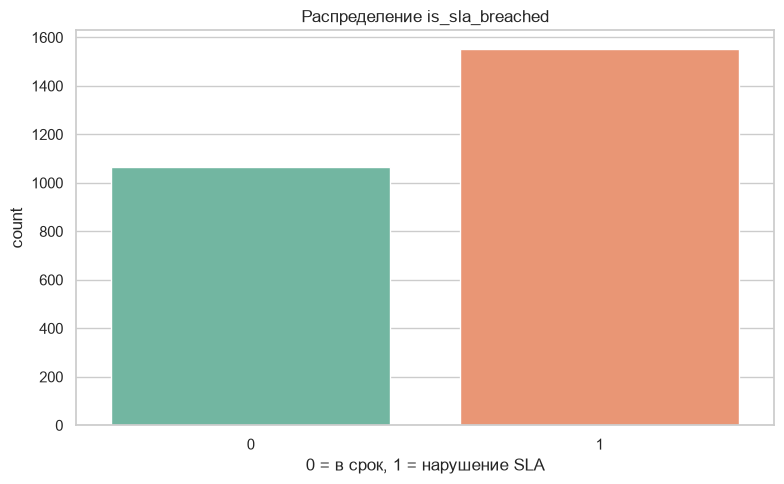

In [12]:
fig, ax = plt.subplots()
sns.countplot(data=clean, x="is_sla_breached", hue="is_sla_breached", ax=ax, palette="Set2", legend=False)
ax.set_title("Распределение is_sla_breached")
ax.set_xlabel("0 = в срок, 1 = нарушение SLA")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=120)
plt.show()

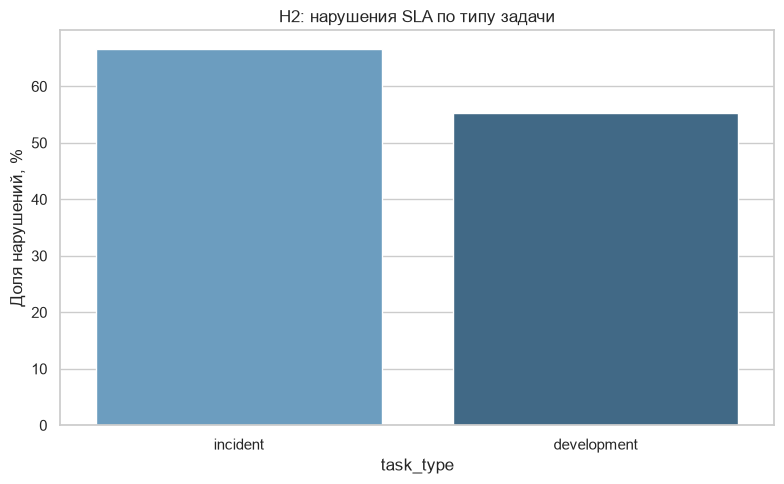

In [13]:
stats = breach_rate_table(clean, "task_type")
fig, ax = plt.subplots()
sns.barplot(data=stats, x="task_type", y="breach_pct", hue="task_type", ax=ax, palette="Blues_d", legend=False)
ax.set_title("Нарушения SLA по типу задачи")
ax.set_ylabel("Доля нарушений, %")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_breach_by_task_type.png", dpi=120)
plt.show()

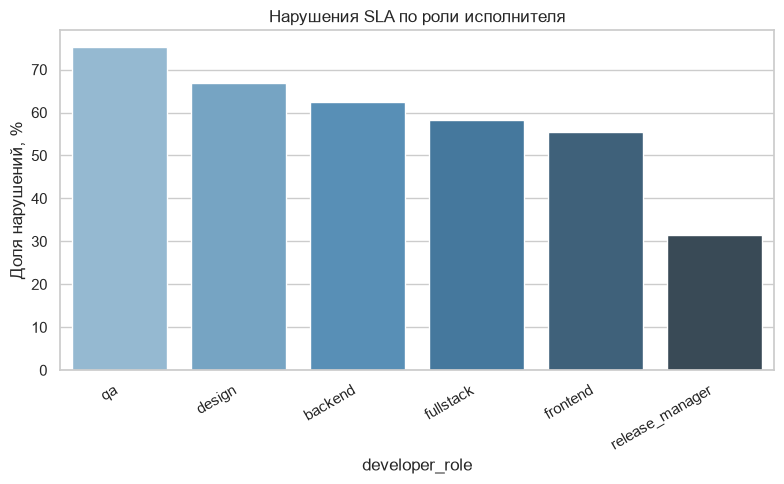

In [19]:
stats = breach_rate_table(clean, "developer_role")
fig, ax = plt.subplots()
sns.barplot(data=stats, x="developer_role", y="breach_pct", hue="developer_role", ax=ax, palette="Blues_d", legend=False)
ax.set_title("Нарушения SLA по роли исполнителя")
ax.set_ylabel("Доля нарушений, %")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_breach_by_role.png", dpi=120)
plt.show()

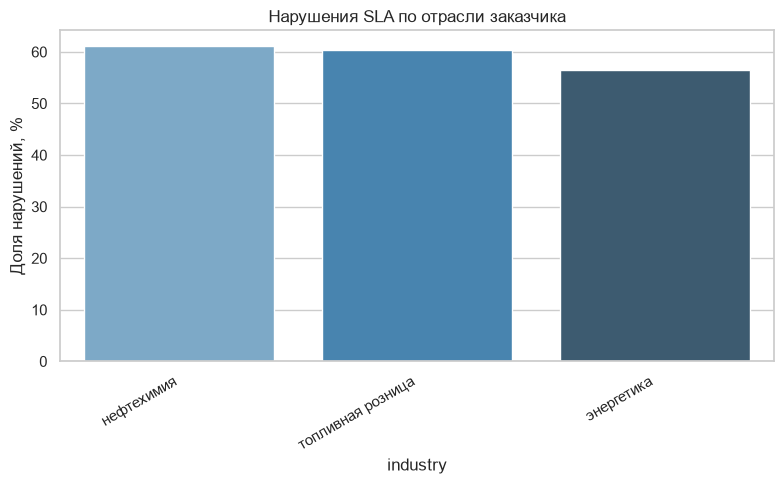

In [18]:
stats = breach_rate_table(clean, "industry")
fig, ax = plt.subplots()
sns.barplot(data=stats, x="industry", y="breach_pct", hue="industry", ax=ax, palette="Blues_d", legend=False)
ax.set_title("Нарушения SLA по отрасли заказчика")
ax.set_ylabel("Доля нарушений, %")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_breach_by_industry.png", dpi=120)
plt.show()

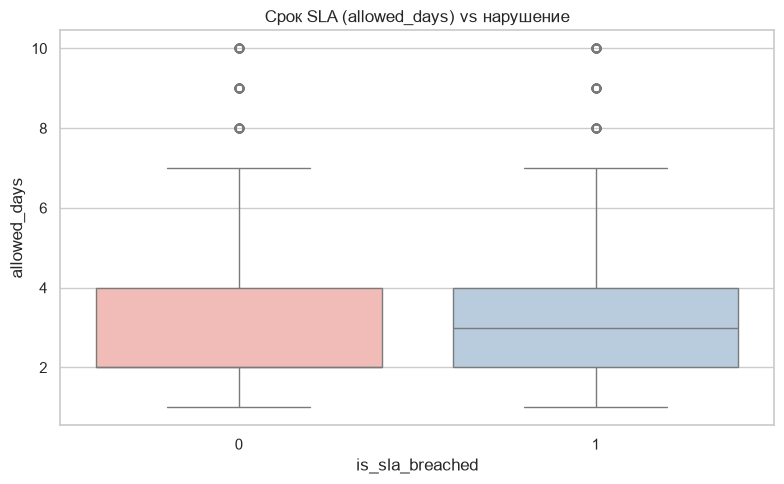

In [14]:
fig, ax = plt.subplots()
sns.boxplot(data=clean, x="is_sla_breached", y="allowed_days", hue="is_sla_breached", ax=ax, palette="Pastel1", legend=False)
ax.set_title("Срок SLA (allowed_days) vs нарушение")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_allowed_days_boxplot.png", dpi=120)
plt.show()

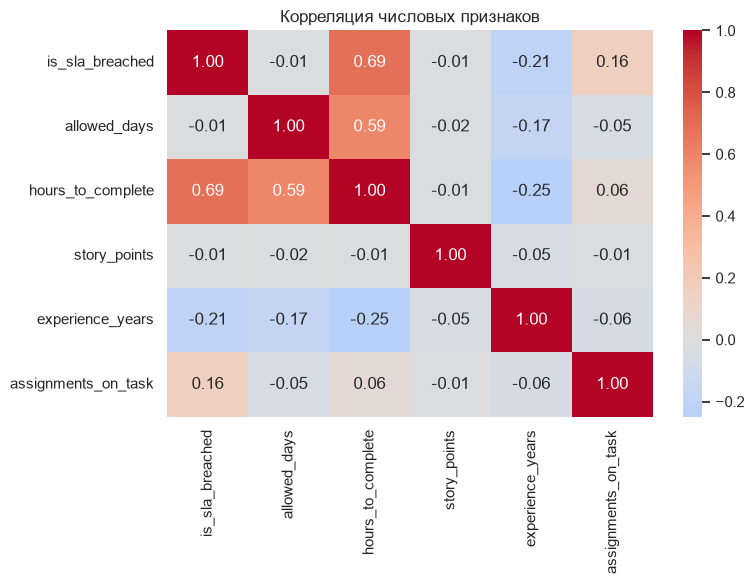

In [21]:
numeric_cols = [
    "is_sla_breached", "allowed_days", "hours_to_complete",
    "story_points", "experience_years", "assignments_on_task",
]
corr = clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляция числовых признаков")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_correlation_heatmap.png", dpi=120)
plt.show()